# 01 - EDA clínico

Exploración de la ficha clínica: dimensiones, tipos, distribuciones, comparación sano vs. Alzheimer.

**Pregunta que responde este notebook:** ¿qué variables clínicas muestran diferencias entre pacientes
sanos y pacientes con Alzheimer en esta cohorte sintética?

**Salidas principales**
- `results/tables/resumen_numericas_por_grupo.csv` — media, mediana, mín, máx y tamaño de efecto
- `results/tables/resumen_binarias_por_grupo.csv` — prevalencias y diferencia en puntos
- `results/tables/variables_seleccionadas.csv` — las 3–5 variables con mayor diferencia
- `results/tables/verificacion_confusion_edad.csv` — control de confusión por edad
- `results/tables/clinica_para_integracion.csv` — insumo del notebook 04
- `results/figures/` — figuras para la presentación

> Los datos son **sintéticos** y de uso docente. Las asociaciones observadas no son evidencia clínica.


## 0. Configuración

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
PALETA = {"Sano": "#4C72B0", "Alzheimer": "#DD8452"}

RANDOM_STATE = 42

### Rutas

Los archivos se buscan automaticamente por nombre: primero en el directorio donde arranco el
kernel, luego en sus dos niveles superiores y en `Downloads`, hasta dos carpetas de profundidad.

Esto evita depender del directorio de trabajo, que en VS Code no siempre coincide con la carpeta
del `.ipynb`. Si aun asi no encuentra los archivos, descomenta `DIR_PROYECTO` y pon la ruta
absoluta de la carpeta del proyecto.

In [2]:
import os
from pathlib import Path

NOMBRE_CLINICO = "synthetic_alzheimer_patients_1000.csv"
NOMBRE_META    = "metadata.json"

# Si la busqueda automatica falla, descomenta y pon aqui la carpeta del proyecto:
# DIR_PROYECTO = Path(r"C:\Users\crist\Downloads\intr_2026_trabajo_final-main\intr_2026_trabajo_final-main")
DIR_PROYECTO = None

CWD = Path(os.getcwd()).resolve()
print("Directorio de trabajo del kernel:", CWD)


def buscar(nombre, raices):
    """Busca un archivo por nombre en varias raices, hasta dos niveles de profundidad."""
    for raiz in raices:
        try:
            if not raiz.exists():
                continue
            if (raiz / nombre).exists():
                return raiz / nombre
            for patron in (f"*/{nombre}", f"*/*/{nombre}"):
                for hallado in raiz.glob(patron):
                    return hallado
        except (PermissionError, OSError):
            continue
    return None


raices = ([Path(DIR_PROYECTO)] if DIR_PROYECTO else []) + [
    CWD, CWD.parent, CWD.parent.parent,
    Path.home() / "Downloads", Path.home(),
]

ARCHIVO_CLINICO = buscar(NOMBRE_CLINICO, raices)
ARCHIVO_META    = buscar(NOMBRE_META, raices)

if ARCHIVO_CLINICO is None:
    raise FileNotFoundError(
        f"No encontre '{NOMBRE_CLINICO}'. Rutas revisadas:\n  "
        + "\n  ".join(str(r) for r in raices)
        + "\n\nDefine DIR_PROYECTO arriba con la ruta absoluta de la carpeta del proyecto."
    )

DIR_DATOS = ARCHIVO_CLINICO.parent
DIR_BASE  = (Path(DIR_PROYECTO) if DIR_PROYECTO
             else (DIR_DATOS.parent if DIR_DATOS.name.lower() == "data" else DIR_DATOS))

DIR_RESULTADOS = DIR_BASE / "results"
DIR_FIGURAS    = DIR_RESULTADOS / "figures"
DIR_TABLAS     = DIR_RESULTADOS / "tables"

for sub in ["distribuciones", "categoricas", "correlacion", "proyecciones", "resumen"]:
    (DIR_FIGURAS / sub).mkdir(parents=True, exist_ok=True)
DIR_TABLAS.mkdir(parents=True, exist_ok=True)

print("Datos clinicos:", ARCHIVO_CLINICO)
print("Metadata:      ", ARCHIVO_META)
print("Resultados en: ", DIR_RESULTADOS)

Directorio de trabajo del kernel: C:\Users\crist\Downloads
Datos clinicos: C:\Users\crist\Downloads\synthetic_alzheimer_patients_1000.csv
Metadata:       C:\Users\crist\Downloads\metadata.json
Resultados en:  C:\Users\crist\Downloads\results


In [3]:
def guardar_figura(nombre, subcarpeta="resumen"):
    """Guarda la figura activa en results/figures/<subcarpeta>/ a 300 dpi."""
    ruta = DIR_FIGURAS / subcarpeta / f"{nombre}.png"
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    return ruta


def guardar_tabla(df, nombre, index=False):
    """Guarda una tabla en results/tables/ y devuelve la ruta."""
    ruta = DIR_TABLAS / f"{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta

---
## 1. Carga y control de calidad

La guía (sección 4.1) pide revisar dimensiones, tipos de variables, valores faltantes y duplicados
antes de cualquier análisis. Es la parte menos vistosa y la primera que preguntan en la defensa.

In [4]:
df = pd.read_csv(ARCHIVO_CLINICO)

with open(ARCHIVO_META, "r", encoding="utf-8") as f:
    metadata = json.load(f)

LABEL   = metadata["label"]        # "alzheimer"
COL_ID  = metadata["col_id"]       # "patient_id"
NUMERICAS = metadata["numerical_column"]
BINARIAS  = metadata["categorical_column"]

print(f"Pacientes (filas):  {df.shape[0]}")
print(f"Variables (columnas): {df.shape[1]}")
print(f"Numéricas: {len(NUMERICAS)} | Binarias: {len(BINARIAS)} | Id: {COL_ID} | Etiqueta: {LABEL}")

df.head()

Pacientes (filas):  1000
Variables (columnas): 31
Numéricas: 10 | Binarias: 19 | Id: patient_id | Etiqueta: alzheimer


,patient_id,age,sex_female,height_cm,weight_kg,bmi,waist_cm,hip_cm,waist_hip_ratio,systolic_bp_mmHg,diastolic_bp_mmHg,heart_rate_bpm,smoker,alcohol_risk,physical_inactivity,hypertension,diabetes_type2,dyslipidemia,cardiovascular_disease,stroke_history,depression_history,traumatic_brain_injury,family_history_alzheimer,sleep_disorder,chronic_kidney_disease,hearing_loss,asthma,allergy_medication,allergy_food,allergy_environmental,alzheimer
0,P0001,75,1,158.7,69.5,27.6,116.6,136.3,0.855,137,77,81,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
1,P0002,50,1,156.5,70.3,28.7,122.1,130.5,0.936,99,78,62,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,P0003,82,0,169.4,76.6,26.7,117.8,118.3,0.996,153,85,73,1,0,1,1,0,0,1,1,0,0,1,1,0,0,0,0,1,0,1
3,P0004,72,1,165.2,80.8,29.6,110.1,123.4,0.892,121,75,73,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
4,P0005,64,1,151.0,75.4,33.0,127.2,144.4,0.881,153,74,84,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0


In [5]:
# Tipos de dato
tipos = (df.dtypes.rename("tipo").to_frame()
         .assign(grupo=lambda t: np.select(
             [t.index == COL_ID, t.index == LABEL,
              t.index.isin(NUMERICAS), t.index.isin(BINARIAS)],
             ["identificador", "diagnostico", "numerica", "binaria"],
             default="sin_clasificar")))

print(tipos["grupo"].value_counts().to_string())
tipos

grupo
binaria          19
numerica         10
identificador     1
diagnostico       1


,tipo,grupo
patient_id,str,identificador
age,int64,numerica
sex_female,int64,binaria
height_cm,float64,numerica
weight_kg,float64,numerica
bmi,float64,numerica
waist_cm,float64,numerica
hip_cm,float64,numerica
waist_hip_ratio,float64,numerica
systolic_bp_mmHg,int64,numerica


In [6]:
# Faltantes y duplicados
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0]

print("Valores faltantes:")
print(faltantes.to_string() if len(faltantes) else "  Ninguno")

print(f"\nFilas completamente duplicadas: {df.duplicated().sum()}")
print(f"{COL_ID} duplicados: {df[COL_ID].duplicated().sum()}")

# Las binarias deberían contener solo 0 y 1
no_binarias = {c: sorted(df[c].dropna().unique())
               for c in BINARIAS if not set(df[c].dropna().unique()) <= {0, 1}}
print("\nColumnas declaradas binarias con valores fuera de {0,1}:",
      no_binarias if no_binarias else "ninguna")

# Rangos plausibles de las numéricas
df[NUMERICAS].describe().T[["min", "max", "mean", "50%"]].round(2)

Valores faltantes:
  Ninguno

Filas completamente duplicadas: 0
patient_id duplicados: 0

Columnas declaradas binarias con valores fuera de {0,1}: ninguna


,min,max,mean,50%
age,40.00,95.00,68.79,69.00
height_cm,145.00,195.00,165.49,165.20
weight_kg,45.00,128.70,74.20,73.10
bmi,18.00,40.00,27.03,27.00
waist_cm,88.90,135.00,118.04,118.10
hip_cm,92.90,145.00,127.48,127.50
waist_hip_ratio,0.82,1.05,0.93,0.92
systolic_bp_mmHg,90.00,173.00,130.81,131.00
diastolic_bp_mmHg,56.00,107.00,79.49,80.00
heart_rate_bpm,48.00,110.00,71.62,72.00


---
## 2. Balance de la cohorte

Cuántos pacientes hay en cada grupo. Es el número que abre la diapositiva de datos.

,n_pacientes,porcentaje
diagnostico,,
Sano,657,65.7
Alzheimer,343,34.3


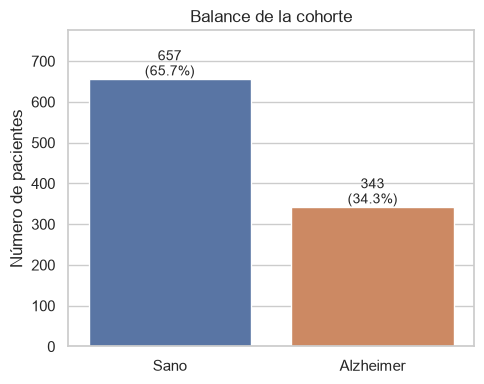

In [7]:
df["diagnostico"] = df[LABEL].map({0: "Sano", 1: "Alzheimer"})

conteo = df["diagnostico"].value_counts()
porcentaje = df["diagnostico"].value_counts(normalize=True).mul(100).round(1)

balance = pd.DataFrame({"n_pacientes": conteo, "porcentaje": porcentaje})
display(balance)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=balance.index, y=balance["n_pacientes"], palette=PALETA, ax=ax)
for i, v in enumerate(balance["n_pacientes"]):
    ax.text(i, v + 8, f"{v}\n({balance['porcentaje'].iloc[i]}%)", ha="center", fontsize=10)
ax.set(xlabel="", ylabel="Número de pacientes", title="Balance de la cohorte")
ax.set_ylim(0, balance["n_pacientes"].max() * 1.18)
plt.tight_layout()
guardar_figura("balance_cohorte")
plt.show()

Undersampling 
de muestra mayoritaria a minoritaria
analisis de redundancia y armas clusters


**Nota para la presentación:** la cohorte está desbalanceada (~2 controles por cada caso).
Eso no impide comparar, pero sí obliga a usar porcentajes en vez de conteos absolutos al
comparar prevalencias entre grupos.

---
## 3. Tabla resumen de variables numéricas

La guía pide media, mediana, mínimo y máximo por grupo. Agregamos el **tamaño de efecto
(d de Cohen)** para poder ordenar las variables por magnitud de la diferencia, en vez de
elegirlas a ojo.

$$d = \frac{\bar{x}_{Alzheimer} - \bar{x}_{sano}}{s_{combinada}}$$

Referencia: |d| ≈ 0.2 pequeño, 0.5 mediano, 0.8 grande. Por debajo de 0.1 es prácticamente ruido.

In [8]:
def d_de_cohen(x, y):
    """Diferencia de medias en unidades de desviación estándar combinada."""
    nx, ny = len(x), len(y)
    s = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / s if s > 0 else 0.0


enfermos = df[df[LABEL] == 1]
sanos    = df[df[LABEL] == 0]

filas = []
for col in NUMERICAS:
    filas.append({
        "variable": col,
        "media_sano": sanos[col].mean(),
        "media_alzheimer": enfermos[col].mean(),
        "mediana_sano": sanos[col].median(),
        "mediana_alzheimer": enfermos[col].median(),
        "min": df[col].min(),
        "max": df[col].max(),
        "diferencia_medias": enfermos[col].mean() - sanos[col].mean(),
        "efecto_d": d_de_cohen(enfermos[col], sanos[col]),
    })

resumen_num = pd.DataFrame(filas).round(3)
resumen_num = resumen_num.reindex(
    resumen_num["efecto_d"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

guardar_tabla(resumen_num, "resumen_numericas_por_grupo")
resumen_num

,variable,media_sano,media_alzheimer,mediana_sano,mediana_alzheimer,min,max,diferencia_medias,efecto_d
0,age,65.654,74.793,65.000,75.000,40.000,95.000,9.139,0.909
1,systolic_bp_mmHg,128.399,135.429,128.000,135.000,90.000,173.000,7.030,0.517
2,diastolic_bp_mmHg,78.953,80.507,79.000,80.000,56.000,107.000,1.554,0.184
3,bmi,26.873,27.333,26.900,27.300,18.000,40.000,0.460,0.109
4,waist_hip_ratio,0.928,0.924,0.925,0.923,0.818,1.051,-0.004,-0.109
5,hip_cm,127.197,128.027,127.100,128.800,92.900,145.000,0.830,0.082
6,weight_kg,73.902,74.771,72.500,74.700,45.000,128.700,0.869,0.063
7,height_cm,165.626,165.217,165.300,164.800,145.000,195.000,-0.409,-0.050
8,heart_rate_bpm,71.521,71.799,72.000,72.000,48.000,110.000,0.278,0.034
9,waist_cm,117.969,118.187,118.100,118.400,88.900,135.000,0.218,0.024


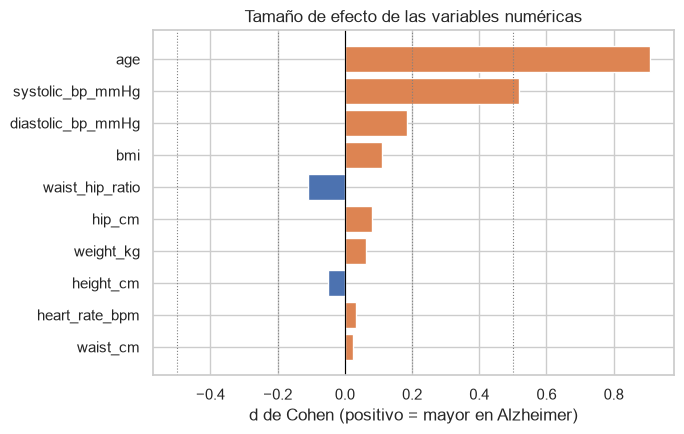

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colores = ["#DD8452" if v > 0 else "#4C72B0" for v in resumen_num["efecto_d"]]
ax.barh(resumen_num["variable"], resumen_num["efecto_d"], color=colores)
for umbral in [-0.5, -0.2, 0.2, 0.5]:
    ax.axvline(umbral, color="grey", ls=":", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.invert_yaxis()
ax.set(xlabel="d de Cohen (positivo = mayor en Alzheimer)", ylabel="",
       title="Tamaño de efecto de las variables numéricas")
plt.tight_layout()
guardar_figura("efecto_numericas")
plt.show()

---
## 4. Tabla resumen de variables binarias

Aquí no hace falta estandarizar: todas están en la misma escala de 0 a 100%.
El criterio de orden es la **diferencia de prevalencia en puntos porcentuales**.

In [10]:
filas = []
for col in BINARIAS:
    p_sano = sanos[col].mean()
    p_alz  = enfermos[col].mean()
    filas.append({
        "variable": col,
        "n_sano": int(sanos[col].sum()),
        "n_alzheimer": int(enfermos[col].sum()),
        "prev_sano_pct": p_sano * 100,
        "prev_alzheimer_pct": p_alz * 100,
        "diferencia_puntos": (p_alz - p_sano) * 100,
        "razon_prevalencias": (p_alz / p_sano) if p_sano > 0 else np.nan,
    })

resumen_bin = pd.DataFrame(filas).round(3)
resumen_bin = resumen_bin.reindex(
    resumen_bin["diferencia_puntos"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

guardar_tabla(resumen_bin, "resumen_binarias_por_grupo")
resumen_bin

,variable,n_sano,n_alzheimer,prev_sano_pct,prev_alzheimer_pct,diferencia_puntos,razon_prevalencias
0,hypertension,175,170,26.636,49.563,22.926,1.861
1,family_history_alzheimer,108,126,16.438,36.735,20.296,2.235
2,hearing_loss,78,95,11.872,27.697,15.825,2.333
3,diabetes_type2,72,85,10.959,24.781,13.822,2.261
4,stroke_history,29,59,4.414,17.201,12.787,3.897
5,physical_inactivity,211,139,32.116,40.525,8.409,1.262
6,depression_history,100,81,15.221,23.615,8.394,1.552
7,cardiovascular_disease,85,70,12.938,20.408,7.471,1.577
8,dyslipidemia,169,113,25.723,32.945,7.222,1.281
9,sleep_disorder,145,96,22.070,27.988,5.918,1.268


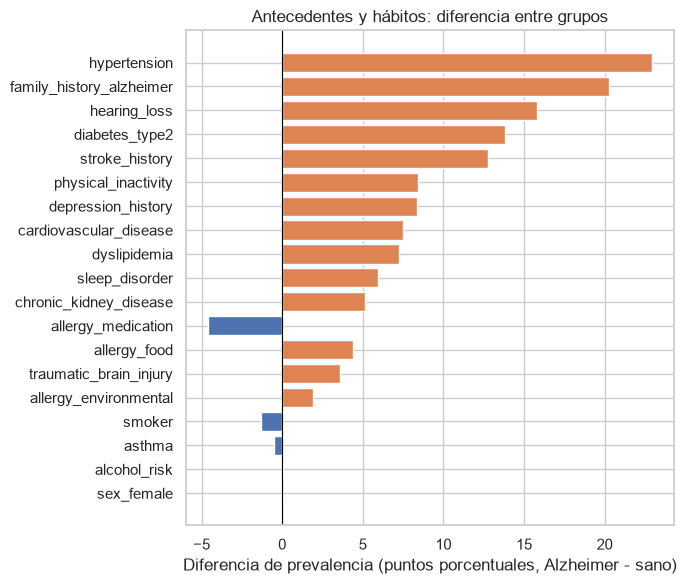

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
colores = ["#DD8452" if v > 0 else "#4C72B0" for v in resumen_bin["diferencia_puntos"]]
ax.barh(resumen_bin["variable"], resumen_bin["diferencia_puntos"], color=colores)
ax.axvline(0, color="black", lw=0.8)
ax.invert_yaxis()
ax.set(xlabel="Diferencia de prevalencia (puntos porcentuales, Alzheimer - sano)",
       ylabel="", title="Antecedentes y hábitos: diferencia entre grupos")
plt.tight_layout()
guardar_figura("efecto_binarias")
plt.show()

Hipertension más relevante


---
## 5. Distribuciones de las variables numéricas

Un histograma y un boxplot por variable, separados por diagnóstico. Se guardan todos,
pero a la presentación van solo 2 o 3.

In [12]:
for col in NUMERICAS:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

    sns.histplot(data=df, x=col, hue="diagnostico", palette=PALETA,
                 kde=True, common_norm=False, stat="density",
                 element="step", fill=False, ax=ax[0])
    ax[0].set(title=f"Distribución de {col}", ylabel="Densidad")

    sns.boxplot(data=df, x="diagnostico", y=col, hue="diagnostico",
                palette=PALETA, legend=False, ax=ax[1])
    d = resumen_num.loc[resumen_num["variable"] == col, "efecto_d"].iloc[0]
    ax[1].set(title=f"{col} por diagnóstico (d = {d:.2f})", xlabel="")

    plt.tight_layout()
    guardar_figura(f"{col}_distribucion", "distribuciones")
    plt.close(fig)

print(f"{len(NUMERICAS)} figuras guardadas en {DIR_FIGURAS / 'distribuciones'}")

10 figuras guardadas en C:\Users\crist\Downloads\results\figures\distribuciones


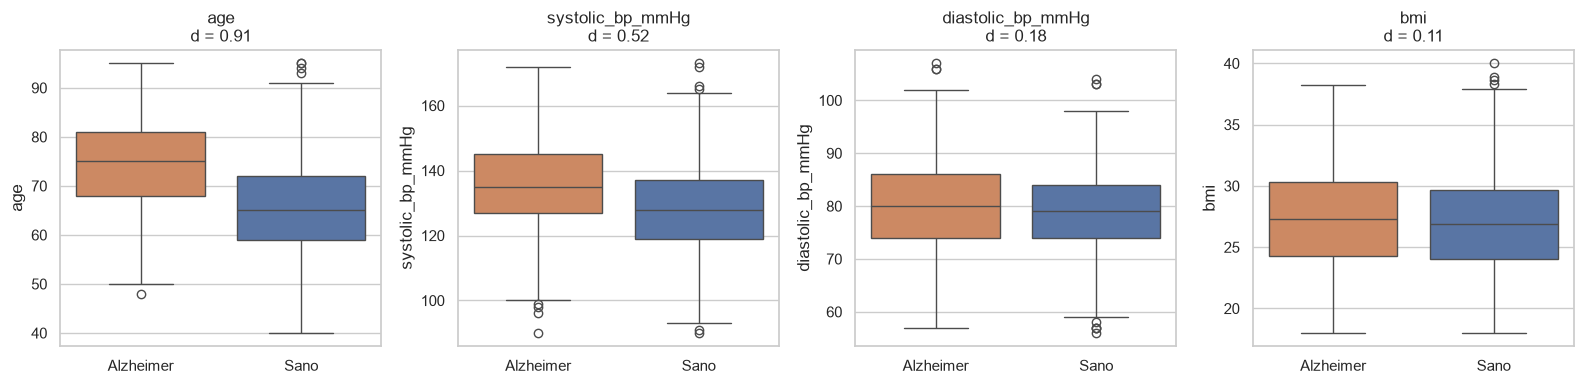

In [13]:
# Panel compacto con las 4 numéricas de mayor efecto (candidata a la presentación)
top4 = resumen_num["variable"].head(4).tolist()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, top4):
    sns.boxplot(data=df, x="diagnostico", y=col, hue="diagnostico",
                palette=PALETA, legend=False, ax=ax)
    d = resumen_num.loc[resumen_num["variable"] == col, "efecto_d"].iloc[0]
    ax.set(title=f"{col}\nd = {d:.2f}", xlabel="")
plt.tight_layout()
guardar_figura("panel_numericas_top")
plt.show()

Hacer violin graficos
DISTRIBUCION Y BOXPLOT
ANALISIS UNIVARIADO
1. CUAL ES LA DATA
2. CUANTO AFECTA LA DATA A NIVEL UNIVARIADO

---
## 6. Prevalencias de las variables binarias

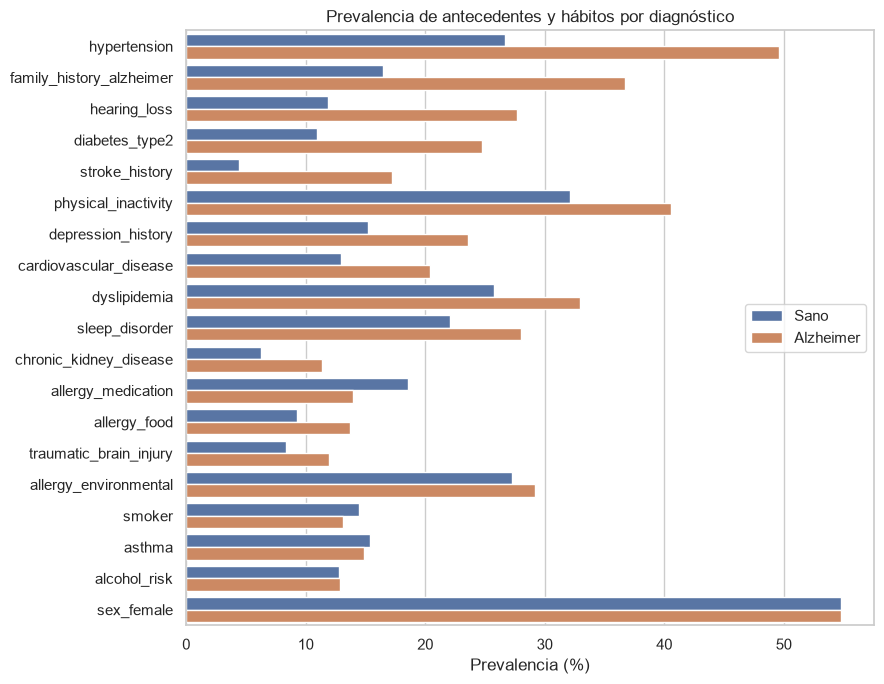

In [14]:
prev = (resumen_bin
        .melt(id_vars="variable",
              value_vars=["prev_sano_pct", "prev_alzheimer_pct"],
              var_name="grupo", value_name="prevalencia")
        .replace({"prev_sano_pct": "Sano", "prev_alzheimer_pct": "Alzheimer"}))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=prev, y="variable", x="prevalencia", hue="grupo",
            palette=PALETA, ax=ax)
ax.set(xlabel="Prevalencia (%)", ylabel="",
       title="Prevalencia de antecedentes y hábitos por diagnóstico")
ax.legend(title="")
plt.tight_layout()
guardar_figura("prevalencias_binarias", "categoricas")
plt.show()

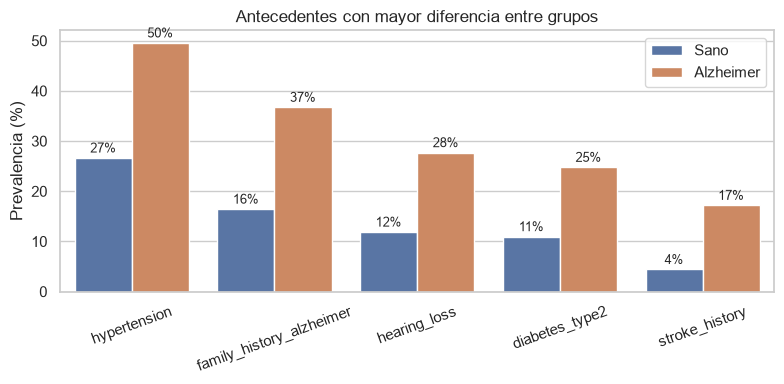

In [15]:
# Panel con las 5 binarias de mayor diferencia
top5_bin = resumen_bin["variable"].head(5).tolist()

sub = prev[prev["variable"].isin(top5_bin)]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=sub, x="variable", y="prevalencia", hue="grupo", palette=PALETA, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", padding=2, fontsize=9)
ax.set(xlabel="", ylabel="Prevalencia (%)",
       title="Antecedentes con mayor diferencia entre grupos")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="")
plt.tight_layout()
guardar_figura("panel_binarias_top", "categoricas")
plt.show()

---
## 7. Correlación entre variables numéricas

Dos usos distintos:

1. **Descriptivo** — qué variables se mueven juntas.
2. **Operativo** — detectar redundancia antes del PCA. Variables con |r| ≥ 0.8 miden
   esencialmente lo mismo, y si entran todas al PCA sobrerrepresentan ese bloque.

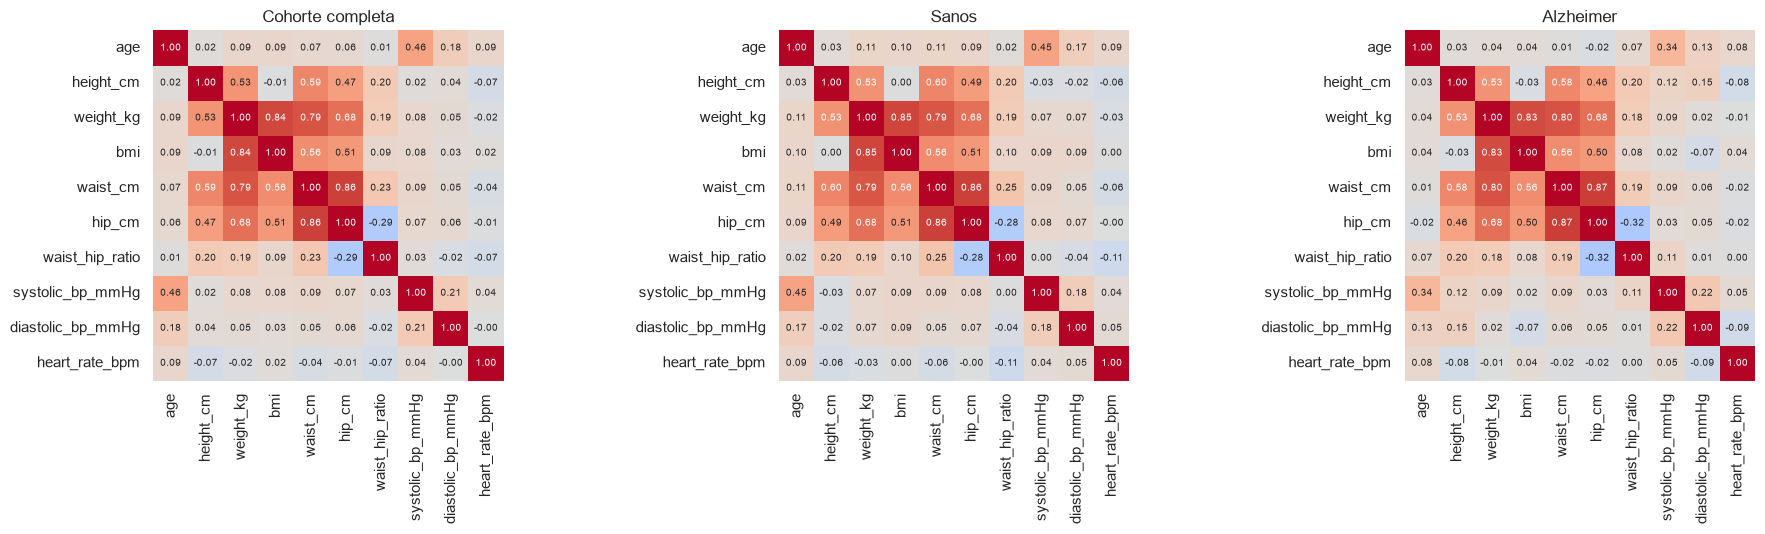

In [ ]:
corr_total = df[NUMERICAS].corr()
corr_sano  = sanos[NUMERICAS].corr()
corr_alz   = enfermos[NUMERICAS].corr()

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, (matriz, titulo) in zip(axes, [(corr_total, "Cohorte completa"),
                                       (corr_sano, "Sanos"),
                                       (corr_alz, "Alzheimer")]):
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, square=True,
                cbar=False, annot_kws={"size": 7}, ax=ax)
    ax.set_title(titulo)
plt.tight_layout()
guardar_figura("matrices_correlacion", "correlacion")
plt.show()

#PEARSON por defecto.

MÁS CERCANOS A CEROS (RELACION) INDICA QE SON INDEPENDIENTES Y HAY QE ANALIZARLOS (POSITIVOS O NEGTIVOS)

In [17]:
UMBRAL_REDUNDANCIA = 0.80

pares = []
for i, a in enumerate(NUMERICAS):
    for b in NUMERICAS[i + 1:]:
        r = corr_total.loc[a, b]
        if abs(r) >= UMBRAL_REDUNDANCIA:
            pares.append({"variable_1": a, "variable_2": b, "r": round(r, 3)})

redundantes = pd.DataFrame(pares)

if len(redundantes):
    efecto = resumen_num.set_index("variable")["efecto_d"].abs()
    redundantes["efecto_1"] = redundantes["variable_1"].map(efecto)
    redundantes["efecto_2"] = redundantes["variable_2"].map(efecto)
    redundantes["se_conserva"] = np.where(
        redundantes["efecto_1"] >= redundantes["efecto_2"],
        redundantes["variable_1"], redundantes["variable_2"])
    redundantes["se_descarta"] = np.where(
        redundantes["efecto_1"] >= redundantes["efecto_2"],
        redundantes["variable_2"], redundantes["variable_1"])
    guardar_tabla(redundantes, "pares_redundantes")
    display(redundantes)
    print("Candidatas a descartar por redundancia:",
          sorted(set(redundantes["se_descarta"])))
else:
    print(f"No hay pares con |r| >= {UMBRAL_REDUNDANCIA}")

,variable_1,variable_2,r,efecto_1,efecto_2,se_conserva,se_descarta
0,weight_kg,bmi,0.839,0.063,0.109,bmi,weight_kg
1,waist_cm,hip_cm,0.864,0.024,0.082,hip_cm,waist_cm


Candidatas a descartar por redundancia: ['waist_cm', 'weight_kg']


**Cómo leerlo:** varias variables antropométricas describen lo mismo. Además, `bmi` se
calcula a partir de `height_cm` y `weight_kg`, y `waist_hip_ratio` a partir de `waist_cm` y
`hip_cm`: son variables **derivadas**, no mediciones independientes. Eso hay que decirlo en
la defensa, porque explica la correlación sin necesidad de invocar biología.

---
## 8. Selección de las 3–5 variables clínicas

Criterio explícito y defendible:

1. Descartar las redundantes detectadas en el paso anterior.
2. Ordenar el resto por tamaño de efecto.
3. Tomar las de mayor efecto, cuidando cubrir dominios clínicos distintos
   (edad, adiposidad, presión, antecedentes).

In [18]:
descartadas = set(redundantes["se_descarta"]) if len(redundantes) else set()

candidatas_num = [v for v in resumen_num["variable"] if v not in descartadas]
print("Numéricas ordenadas por efecto (sin redundantes):")
for v in candidatas_num:
    d = resumen_num.loc[resumen_num["variable"] == v, "efecto_d"].iloc[0]
    print(f"   {v:<20} d = {d:+.3f}")

print("\nBinarias ordenadas por diferencia de prevalencia:")
for _, fila in resumen_bin.head(6).iterrows():
    print(f"   {fila['variable']:<26} {fila['diferencia_puntos']:+.1f} puntos")

Numéricas ordenadas por efecto (sin redundantes):
   age                  d = +0.909
   systolic_bp_mmHg     d = +0.517
   diastolic_bp_mmHg    d = +0.184
   bmi                  d = +0.109
   waist_hip_ratio      d = -0.109
   hip_cm               d = +0.082
   height_cm            d = -0.050
   heart_rate_bpm       d = +0.034

Binarias ordenadas por diferencia de prevalencia:
   hypertension               +22.9 puntos
   family_history_alzheimer   +20.3 puntos
   hearing_loss               +15.8 puntos
   diabetes_type2             +13.8 puntos
   stroke_history             +12.8 puntos
   physical_inactivity        +8.4 puntos


In [19]:
# Propuesta automática: las de mayor efecto que no fueron descartadas por redundancia.
# EDITAR si quieres forzar otra combinación (p. ej. cubrir un dominio clínico distinto).
VARIABLES_NUMERICAS_SEL = candidatas_num[:3]
VARIABLES_BINARIAS_SEL  = resumen_bin["variable"].head(2).tolist()

print("Numéricas seleccionadas:", VARIABLES_NUMERICAS_SEL)
print("Binarias seleccionadas: ", VARIABLES_BINARIAS_SEL)

seleccion = pd.concat([
    resumen_num[resumen_num["variable"].isin(VARIABLES_NUMERICAS_SEL)]
        .assign(tipo="numerica", criterio="tamaño de efecto (d de Cohen)")
        [["variable", "tipo", "criterio", "efecto_d"]]
        .rename(columns={"efecto_d": "magnitud"}),
    resumen_bin[resumen_bin["variable"].isin(VARIABLES_BINARIAS_SEL)]
        .assign(tipo="binaria", criterio="diferencia de prevalencia (puntos)")
        [["variable", "tipo", "criterio", "diferencia_puntos"]]
        .rename(columns={"diferencia_puntos": "magnitud"}),
], ignore_index=True)

guardar_tabla(seleccion, "variables_seleccionadas")
seleccion

Numéricas seleccionadas: ['age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg']
Binarias seleccionadas:  ['hypertension', 'family_history_alzheimer']


,variable,tipo,criterio,magnitud
0,age,numerica,tamaño de efecto (d de Cohen),0.909
1,systolic_bp_mmHg,numerica,tamaño de efecto (d de Cohen),0.517
2,diastolic_bp_mmHg,numerica,tamaño de efecto (d de Cohen),0.184
3,hypertension,binaria,diferencia de prevalencia (puntos),22.926
4,family_history_alzheimer,binaria,diferencia de prevalencia (puntos),20.296


### Redacción para la presentación

Las variables con mayor diferencia entre grupos fueron la **edad** (d = 0.91; 74.8 años en
promedio en pacientes con Alzheimer frente a 65.7 en sanos) y la **presión sistólica** (d = 0.52;
135.4 frente a 128.4 mmHg). Entre los antecedentes destacan **hipertensión** (49.6% frente a
26.6%), **antecedente familiar de Alzheimer** (36.7% frente a 16.4%), **hipoacusia** (27.7% frente
a 11.9%), **diabetes tipo 2** (24.8% frente a 11.0%) y **antecedente de ACV** (17.2% frente a
4.4%, la razón de prevalencias más alta de la cohorte: 3.9 veces).

Las variables **antropométricas no mostraron diferencias** (todas con |d| ≤ 0.11), pese a
representar 6 de las 10 variables numéricas disponibles. Es un resultado útil: acota dónde hay
señal y dónde no.

**Precaución con la edad como factor de confusión.** Los pacientes con Alzheimer son en promedio
9 años mayores, y la edad se correlaciona con la presión sistólica (r = 0.46). Al estratificar por
grupo etario, la diferencia en presión sistólica se reduce de 7 mmHg a 1.5–3 mmHg, es decir que la
edad explica buena parte de ese efecto. En cambio la hipertensión **sigue siendo más frecuente en
Alzheimer dentro de cada estrato de edad** (12.9% vs 26.9% en 40–60; 22.4% vs 41.3% en 61–70;
41.7% vs 50.0% en 71–80; 54.3% vs 62.4% en 81+), por lo que esa asociación no se explica solo por
la edad.


---
## 8.1 Verificación: ¿la edad confunde las demás diferencias?

La edad es la variable con mayor efecto de la cohorte, y muchas condiciones clínicas aumentan
con la edad. Entonces surge la pregunta obligada: cuando vemos más hipertensión en el grupo
Alzheimer, ¿es porque tienen Alzheimer o simplemente porque son mayores?

La forma más simple de responderlo sin estadística avanzada es la **comparación estratificada**:
dividir la cohorte en grupos de edad y repetir la comparación *dentro* de cada grupo. Si la
diferencia persiste en todos los estratos, no se explica solo por la edad. Si se desvanece, la
edad era la responsable.

Esto es exactamente lo que la pauta pide en la dimensión de rigor: distinguir entre una
asociación observada y una interpretación.

In [20]:
# Correlación de la edad con las demás numéricas: quién puede estar arrastrado por ella
corr_edad = (df[NUMERICAS].corr()["age"]
             .drop("age").sort_values(key=abs, ascending=False)
             .rename("r_con_edad").to_frame().round(3))
display(corr_edad)

# Estratos de edad. Se usan cortes fijos para que los grupos sean interpretables.
CORTES_EDAD = [39, 60, 70, 80, 120]
ETIQUETAS_EDAD = ["40-60", "61-70", "71-80", "81+"]

df["grupo_edad"] = pd.cut(df["age"], bins=CORTES_EDAD, labels=ETIQUETAS_EDAD)

n_estratos = pd.crosstab(df["grupo_edad"], df["diagnostico"])
print("\nPacientes por estrato y diagnóstico:")
display(n_estratos)
print("Atención: los estratos con pocos pacientes en algún grupo son poco confiables.")

,r_con_edad
systolic_bp_mmHg,0.459
diastolic_bp_mmHg,0.177
bmi,0.092
weight_kg,0.089
heart_rate_bpm,0.088
waist_cm,0.072
hip_cm,0.064
height_cm,0.019
waist_hip_ratio,0.010



Pacientes por estrato y diagnóstico:


diagnostico,Alzheimer,Sano
grupo_edad,,
40-60,26,202
61-70,92,241
71-80,124,168
81+,101,46


Atención: los estratos con pocos pacientes en algún grupo son poco confiables.


In [21]:
def comparar_estratificado(variable, es_binaria):
    """Compara una variable entre grupos, primero cruda y luego dentro de cada estrato de edad."""
    if es_binaria:
        crudo = df.groupby("diagnostico", observed=True)[variable].mean().mul(100)
        estrat = (df.groupby(["grupo_edad", "diagnostico"], observed=True)[variable]
                    .mean().mul(100).unstack())
        unidad = "%"
    else:
        crudo = df.groupby("diagnostico", observed=True)[variable].mean()
        estrat = (df.groupby(["grupo_edad", "diagnostico"], observed=True)[variable]
                    .mean().unstack())
        unidad = ""

    estrat = estrat[["Sano", "Alzheimer"]]
    estrat["diferencia"] = estrat["Alzheimer"] - estrat["Sano"]

    dif_cruda = crudo["Alzheimer"] - crudo["Sano"]
    dif_media_estratos = estrat["diferencia"].mean()

    return estrat.round(1), dif_cruda, dif_media_estratos, unidad


resultados_confusion = []

for variable in VARIABLES_NUMERICAS_SEL + VARIABLES_BINARIAS_SEL:
    if variable == "age":
        continue   # no tiene sentido estratificar la edad por edad

    es_bin = variable in BINARIAS
    estrat, dif_cruda, dif_estrat, unidad = comparar_estratificado(variable, es_bin)

    retencion = (dif_estrat / dif_cruda * 100) if dif_cruda != 0 else np.nan
    mismo_signo = int((np.sign(estrat["diferencia"]) == np.sign(dif_cruda)).sum())
    total_estratos = len(estrat)

    if mismo_signo == total_estratos and retencion >= 50:
        veredicto = "se mantiene en todos los estratos"
    elif mismo_signo == total_estratos and retencion >= 25:
        veredicto = "persiste pero atenuada por la edad"
    else:
        veredicto = "en gran medida explicada por la edad"

    print(f"\n=== {variable} ===")
    print(f"Diferencia cruda (Alzheimer - Sano): {dif_cruda:+.1f}{unidad}")
    print(f"Diferencia media dentro de estratos: {dif_estrat:+.1f}{unidad} "
          f"({retencion:.0f}% de la cruda) | mismo signo en {mismo_signo}/{total_estratos} estratos")
    print(f"-> {veredicto}")
    display(estrat)

    resultados_confusion.append({
        "variable": variable,
        "tipo": "binaria" if es_bin else "numerica",
        "diferencia_cruda": round(dif_cruda, 2),
        "diferencia_estratificada": round(dif_estrat, 2),
        "retencion_pct": round(retencion, 1),
        "estratos_mismo_signo": f"{mismo_signo}/{total_estratos}",
        "interpretacion": veredicto,
    })

tabla_confusion = pd.DataFrame(resultados_confusion)
guardar_tabla(tabla_confusion, "verificacion_confusion_edad")
tabla_confusion


=== systolic_bp_mmHg ===
Diferencia cruda (Alzheimer - Sano): +7.0
Diferencia media dentro de estratos: +3.2 (45% de la cruda) | mismo signo en 4/4 estratos
-> persiste pero atenuada por la edad


diagnostico,Sano,Alzheimer,diferencia
grupo_edad,,,
40-60,122.0,127.8,5.8
61-70,128.0,130.5,2.5
71-80,133.7,135.2,1.6
81+,139.2,142.1,2.8



=== diastolic_bp_mmHg ===
Diferencia cruda (Alzheimer - Sano): +1.6
Diferencia media dentro de estratos: +0.3 (20% de la cruda) | mismo signo en 3/4 estratos
-> en gran medida explicada por la edad


diagnostico,Sano,Alzheimer,diferencia
grupo_edad,,,
40-60,77.3,76.8,-0.5
61-70,78.8,79.9,1.1
71-80,80.5,80.7,0.2
81+,81.4,81.8,0.4



=== hypertension ===
Diferencia cruda (Alzheimer - Sano): +22.9%
Diferencia media dentro de estratos: +12.3% (54% de la cruda) | mismo signo en 4/4 estratos
-> se mantiene en todos los estratos


diagnostico,Sano,Alzheimer,diferencia
grupo_edad,,,
40-60,12.9,26.9,14.1
61-70,22.4,41.3,18.9
71-80,41.7,50.0,8.3
81+,54.3,62.4,8.0



=== family_history_alzheimer ===
Diferencia cruda (Alzheimer - Sano): +20.3%
Diferencia media dentro de estratos: +21.7% (107% de la cruda) | mismo signo en 4/4 estratos
-> se mantiene en todos los estratos


diagnostico,Sano,Alzheimer,diferencia
grupo_edad,,,
40-60,17.3,42.3,25.0
61-70,14.9,37.0,22.0
71-80,18.5,39.5,21.1
81+,13.0,31.7,18.6


,variable,tipo,diferencia_cruda,diferencia_estratificada,retencion_pct,estratos_mismo_signo,interpretacion
0,systolic_bp_mmHg,numerica,7.03,3.19,45.4,4/4,persiste pero atenuada por la edad
1,diastolic_bp_mmHg,numerica,1.55,0.30,19.5,3/4,en gran medida explicada por la edad
2,hypertension,binaria,22.93,12.33,53.8,4/4,se mantiene en todos los estratos
3,family_history_alzheimer,binaria,20.30,21.68,106.8,4/4,se mantiene en todos los estratos


### Cómo leer la tabla

`retencion_pct` compara la diferencia dentro de estratos contra la diferencia cruda:

- **≥ 50% y mismo signo en todos los estratos** — la asociación se sostiene al controlar edad.
- **25–50% y mismo signo** — persiste, pero la edad explica parte del efecto.
- **< 25% o signo inconsistente** — la diferencia era en gran medida un efecto de edad.

El signo importa tanto como la magnitud: una diferencia que cambia de dirección entre estratos
no es una asociación estable, por muy grande que sea el promedio.

Ojo con los estratos de pocos pacientes: una prevalencia calculada sobre 26 personas es
inestable. Por eso la tabla de conteos del paso anterior se imprime primero.

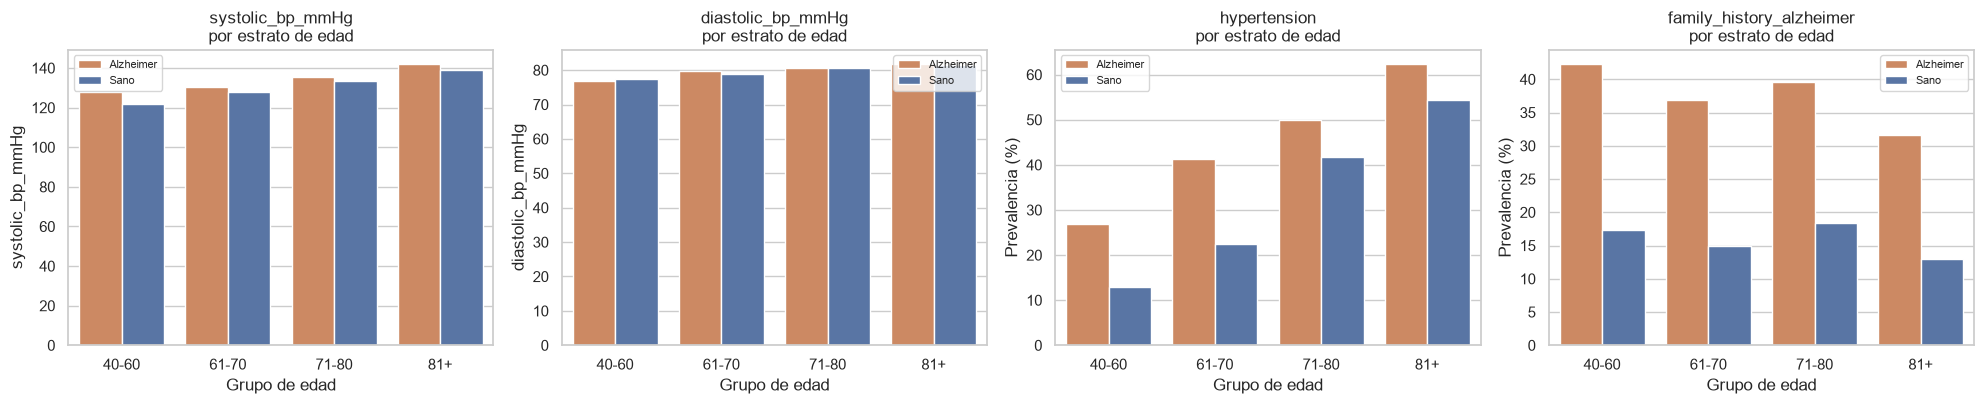

In [22]:
variables_grafico = [v for v in VARIABLES_NUMERICAS_SEL + VARIABLES_BINARIAS_SEL if v != "age"]
n = len(variables_grafico)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.2))
axes = np.atleast_1d(axes)

for ax, variable in zip(axes, variables_grafico):
    es_bin = variable in BINARIAS
    datos = (df.groupby(["grupo_edad", "diagnostico"], observed=True)[variable]
               .mean().mul(100 if es_bin else 1).reset_index())

    sns.barplot(data=datos, x="grupo_edad", y=variable, hue="diagnostico",
                palette=PALETA, ax=ax)
    ax.set(xlabel="Grupo de edad",
           ylabel="Prevalencia (%)" if es_bin else variable,
           title=f"{variable}\npor estrato de edad")
    ax.legend(title="", fontsize=8)

plt.tight_layout()
guardar_figura("confusion_por_edad", "resumen")
plt.show()

**Qué decir en la defensa.**

Pregunta esperable: *"Los pacientes con Alzheimer son 9 años mayores. ¿No será que todas las
diferencias que encontraron son solo efecto de la edad?"*

Respuesta directa: lo verificamos estratificando por grupo etario y repitiendo la comparación
dentro de cada estrato. La hipertensión se mantiene más frecuente en el grupo Alzheimer en los
cuatro estratos, así que esa asociación no se explica solo por la edad. La presión sistólica, en
cambio, se atenúa bastante: la edad explica buena parte de esa diferencia.

Límite: sigue siendo una comparación descriptiva, no un ajuste estadístico formal, y los datos
son sintéticos.

---
## 9. Verificación: ¿el sexo confunde las comparaciones?

El sexo condiciona talla, peso y perímetros corporales. Si los grupos estuvieran desbalanceados
por sexo, una diferencia antropométrica podría reflejar composición del grupo y no diagnóstico.

In [23]:
tabla_sexo = pd.crosstab(df["diagnostico"], df["sex_female"], normalize="index").mul(100).round(1)
tabla_sexo.columns = ["Hombre (%)", "Mujer (%)"]
display(tabla_sexo)

dif_sexo = abs(tabla_sexo.loc["Alzheimer", "Mujer (%)"] - tabla_sexo.loc["Sano", "Mujer (%)"])
print(f"Diferencia en proporción de mujeres entre grupos: {dif_sexo:.1f} puntos")
print("Los grupos están razonablemente balanceados por sexo."
      if dif_sexo < 10 else
      "Atención: desbalance por sexo, interpretar con cuidado las variables antropométricas.")

# Comparación estratificada
estratificado = (df.groupby(["sex_female", "diagnostico"])[NUMERICAS]
                   .mean().round(2))
estratificado

,Hombre (%),Mujer (%)
diagnostico,,
Alzheimer,45.2,54.8
Sano,45.2,54.8


Diferencia en proporción de mujeres entre grupos: 0.0 puntos
Los grupos están razonablemente balanceados por sexo.


age  height_cm  weight_kg    bmi  waist_cm  hip_cm  waist_hip_ratio  systolic_bp_mmHg  diastolic_bp_mmHg  heart_rate_bpm
sex_female diagnostico                                                                                                                            
0          Alzheimer    75.67     169.29      77.99  27.18    120.52  128.87             0.94            137.50              81.46           71.41
           Sano         66.14     169.84      77.60  26.84    121.04  128.90             0.94            127.81              79.06           71.11
1          Alzheimer    74.07     161.86      72.12  27.46    116.26  127.33             0.91            133.72              79.72           72.12
           Sano         65.25     162.15      70.85  26.90    115.43  125.79             0.92            128.88              78.87           71.86

---
## 10. Proyección PCA

El PCA se aplica **solo a variables numéricas estandarizadas y no redundantes**. Las binarias
quedan fuera: estandarizar un 0/1 no produce una distancia interpretable.

Es un método **no supervisado**: busca los ejes de máxima varianza, no los que separan sanos de
enfermos. Si los grupos no se separan, es un resultado válido, no un error.

In [ ]:
# Todas las numéricas no redundantes, hasta un máximo de 5.
# EDITAR si prefieres fijar la lista a mano.
VARIABLES_PCA = candidatas_num[:5]
print("Variables que entran al PCA:", VARIABLES_PCA)

X = df[VARIABLES_PCA]
X_esc = StandardScaler().fit_transform(X)

pca = PCA(random_state=RANDOM_STATE)
#valor controlado
scores = pca.fit_transform(X_esc)

var_exp = pca.explained_variance_ratio_
print("Varianza explicada por componente (%):", np.round(var_exp * 100, 1))
print(f"Acumulada PC1 + PC2: {var_exp[:2].sum() * 100:.1f}%")

df_pca = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"])
df_pca["diagnostico"] = df["diagnostico"].values
df_pca["sex_female"]  = df["sex_female"].values

cargas = pd.DataFrame(pca.components_[:2].T, index=VARIABLES_PCA, #REVISAR
                      columns=["PC1", "PC2"]).round(3)
display(cargas)


Variables que entran al PCA: ['age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'bmi', 'waist_hip_ratio']
Varianza explicada por componente (%): [32.3 21.6 18.  17.3 10.8]
Acumulada PC1 + PC2: 53.9%


,PC1,PC2
age,0.623,-0.051
systolic_bp_mmHg,0.634,-0.060
diastolic_bp_mmHg,0.406,-0.235
bmi,0.205,0.620
waist_hip_ratio,0.050,0.744


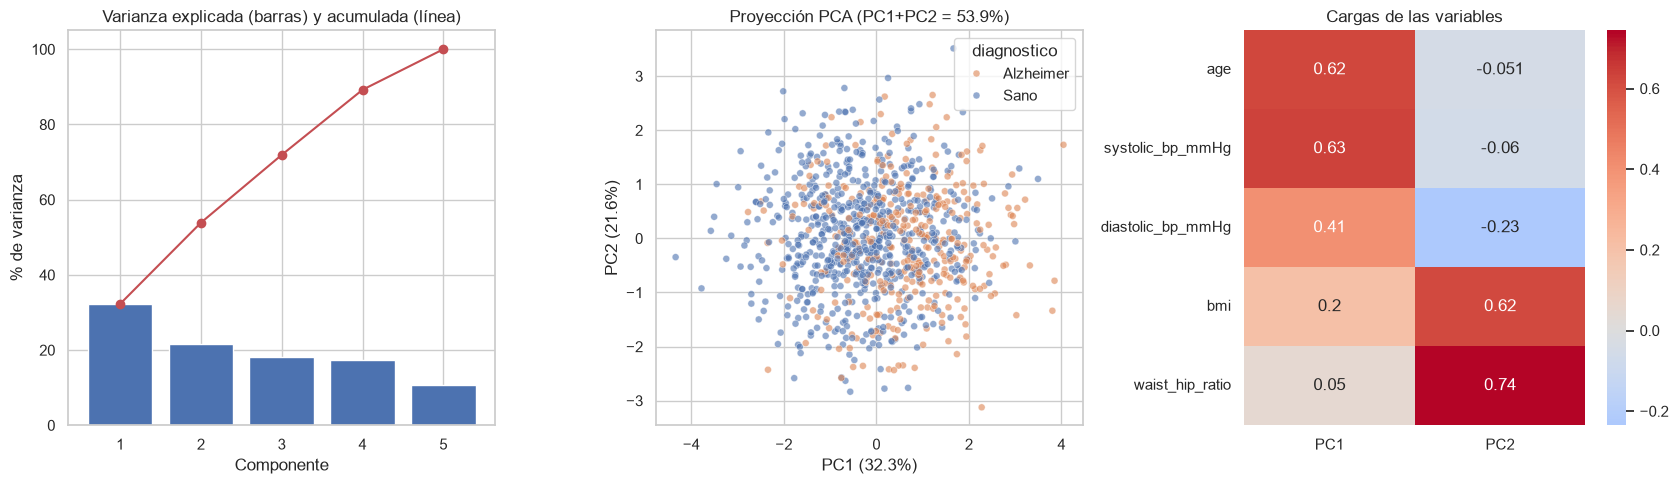

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))

ax[0].bar(range(1, len(var_exp) + 1), var_exp * 100, color="#4C72B0")
ax[0].plot(range(1, len(var_exp) + 1), np.cumsum(var_exp) * 100, "o-", color="#C44E52")
ax[0].set(xlabel="Componente", ylabel="% de varianza",
          title="Varianza explicada (barras) y acumulada (línea)")

sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="diagnostico",
                palette=PALETA, alpha=0.6, s=25, ax=ax[1])
ax[1].set(xlabel=f"PC1 ({var_exp[0]*100:.1f}%)", ylabel=f"PC2 ({var_exp[1]*100:.1f}%)",
          title=f"Proyección PCA (PC1+PC2 = {var_exp[:2].sum()*100:.1f}%)")

sns.heatmap(cargas, annot=True, cmap="coolwarm", center=0, ax=ax[2])
ax[2].set_title("Cargas de las variables")

plt.tight_layout()
guardar_figura("pca_panel", "proyecciones")
plt.show()

VARIANZA ACUMULADA POR 1, 2 , 3 COMPONENTES. Variables proyectadas
plot 2. separación no es trivial, hay datos sobrelapandose
plot 3. lo sacamos, hacer scaterplo entre diferentes componentes
pair plot

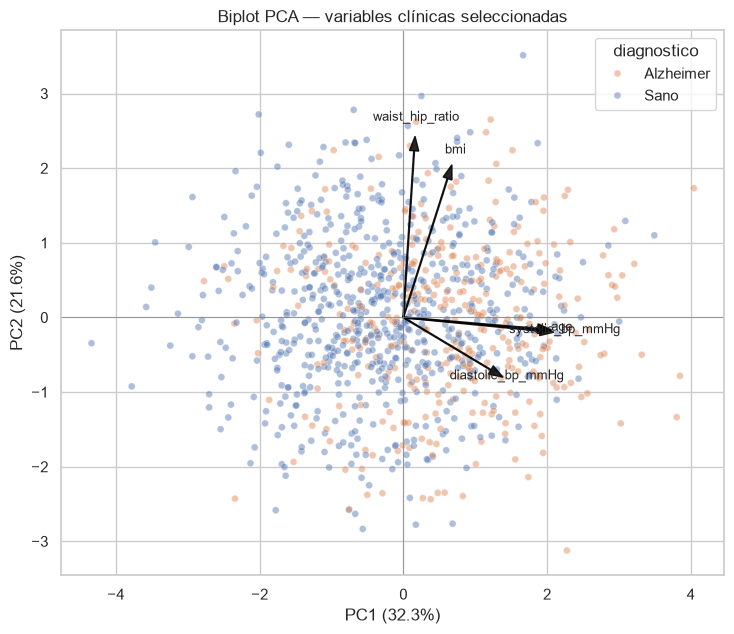

In [ ]:
# Biplot: pacientes + flechas de las variables
fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="diagnostico",
                palette=PALETA, alpha=0.45, s=25, ax=ax)

escala = 3
for i, v in enumerate(VARIABLES_PCA):
    ax.arrow(0, 0, pca.components_[0, i] * escala, pca.components_[1, i] * escala,
             color="black", width=0.012, head_width=0.13, alpha=0.85)
    ax.text(pca.components_[0, i] * escala * 1.18,
            pca.components_[1, i] * escala * 1.18, v, fontsize=9, ha="center")

ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set(xlabel=f"PC1 ({var_exp[0]*100:.1f}%)", ylabel=f"PC2 ({var_exp[1]*100:.1f}%)",
       title="Biplot PCA — variables clínicas seleccionadas")
plt.tight_layout()
guardar_figura("pca_biplot", "proyecciones")
plt.show()

# biplot no relevante, borrar

Efecto entre grupos sobre los componentes:
   PC1: d = +0.781
   PC2: d = -0.124


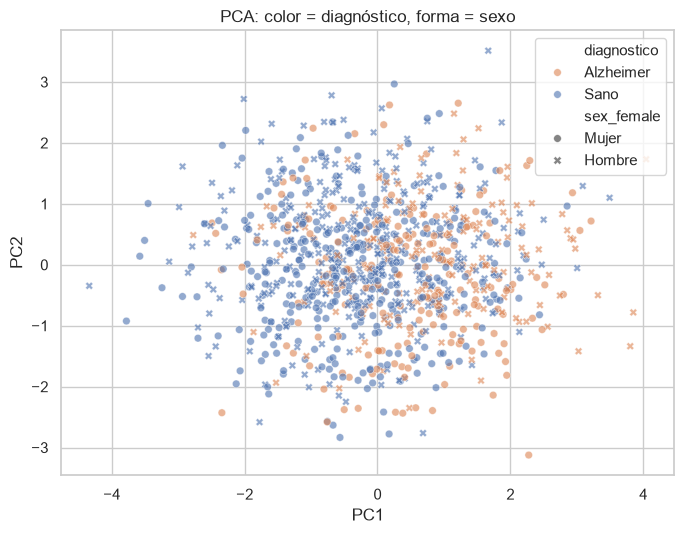

In [27]:
# ¿Los componentes separan los grupos? ¿O separan por sexo?
print("Efecto entre grupos sobre los componentes:")
for pc in ["PC1", "PC2"]:
    d = d_de_cohen(df_pca[df_pca["diagnostico"] == "Alzheimer"][pc],
                   df_pca[df_pca["diagnostico"] == "Sano"][pc])
    print(f"   {pc}: d = {d:+.3f}")

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="diagnostico",
                style=df_pca["sex_female"].map({0: "Hombre", 1: "Mujer"}),
                palette=PALETA, alpha=0.6, s=30, ax=ax)
ax.set(title="PCA: color = diagnóstico, forma = sexo")
plt.tight_layout()
guardar_figura("pca_por_sexo", "proyecciones")
plt.show()

var categoricas que importan mas, en vez de sexo considerar historial familiar en vez de sexo (cambiar)

**Cómo interpretarlo en la defensa.**

En esta cohorte PC1 **sí discrimina parcialmente**: está dominado por edad y presión sistólica,
que son las dos variables con mayor tamaño de efecto, y el efecto entre grupos sobre PC1 es
d ≈ 0.78. PC2 recoge el bloque antropométrico (BMI, índice cintura-cadera) y no discrimina nada
(d ≈ -0.12).

Pero mirar la nube es igual de importante que mirar el número: los grupos **se desplazan pero se
superponen ampliamente**. Un desplazamiento de medias no es una separación limpia. Con esta
proyección no se podría clasificar a un paciente individual, solo describir una tendencia
poblacional.

Ese es el argumento que conecta con las capas moleculares: la información clínica captura parte
de la diferencia entre grupos, pero deja un solape grande, y las capas de DNA y proteína pueden
aportar información **complementaria** sobre los pacientes que caen en la zona compartida.

Conviene además revisar el gráfico por sexo: si hombres y mujeres quedaran en zonas distintas del
plano, el PCA estaría capturando sexo antes que diagnóstico. En esta cohorte los grupos están
balanceados por sexo (54.8% de mujeres en ambos), así que ese riesgo está descartado.


---
## 11. Figura resumen de la cohorte

Una sola figura para la diapositiva de resultados clínicos.

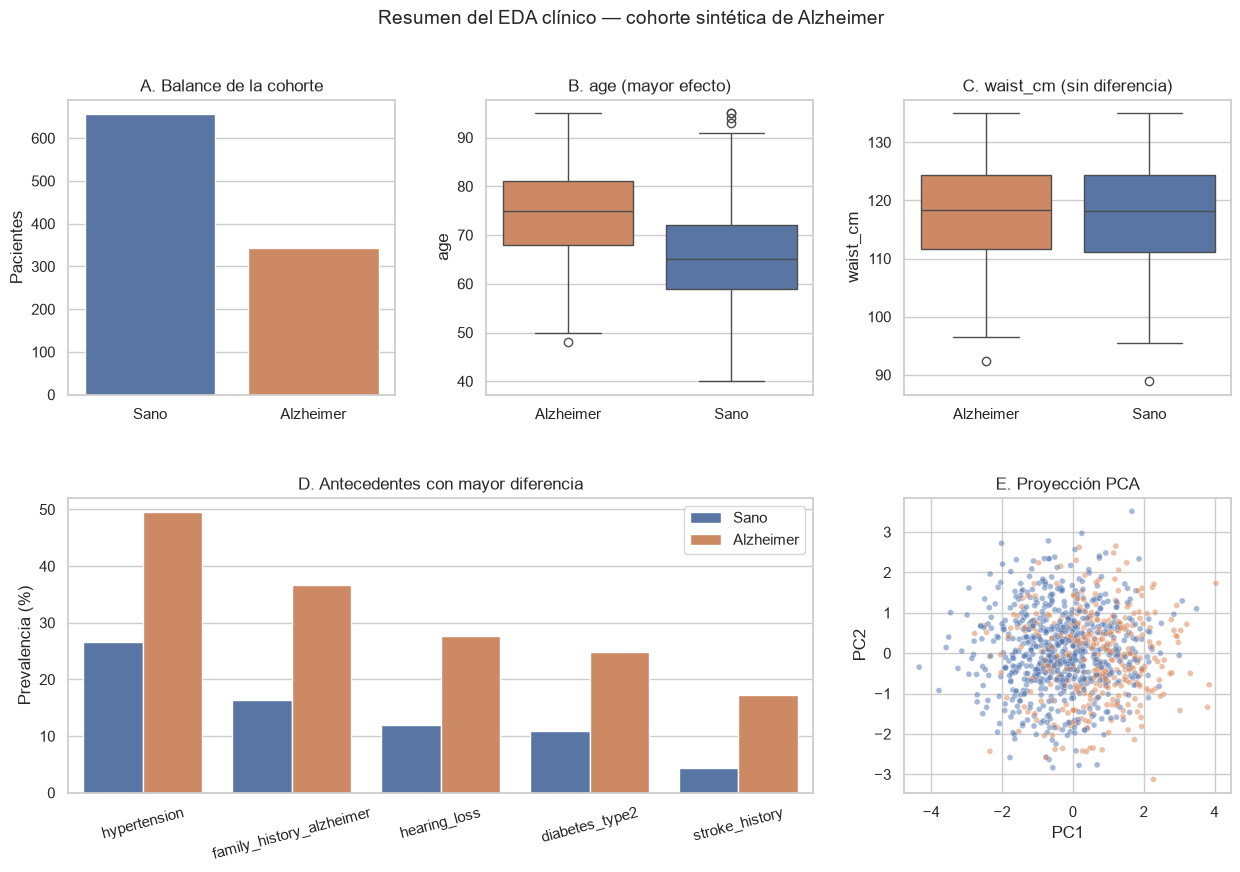

In [28]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(x=balance.index, y=balance["n_pacientes"], palette=PALETA, ax=ax1)
ax1.set(title="A. Balance de la cohorte", xlabel="", ylabel="Pacientes")

var_top = resumen_num["variable"].iloc[0]
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df, x="diagnostico", y=var_top, hue="diagnostico",
            palette=PALETA, legend=False, ax=ax2)
ax2.set(title=f"B. {var_top} (mayor efecto)", xlabel="")

var_nula = resumen_num["variable"].iloc[-1]
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df, x="diagnostico", y=var_nula, hue="diagnostico",
            palette=PALETA, legend=False, ax=ax3)
ax3.set(title=f"C. {var_nula} (sin diferencia)", xlabel="")

ax4 = fig.add_subplot(gs[1, :2])
sns.barplot(data=prev[prev["variable"].isin(top5_bin)],
            x="variable", y="prevalencia", hue="grupo", palette=PALETA, ax=ax4)
ax4.set(title="D. Antecedentes con mayor diferencia", xlabel="", ylabel="Prevalencia (%)")
ax4.tick_params(axis="x", rotation=15)
ax4.legend(title="")

ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="diagnostico",
                palette=PALETA, alpha=0.5, s=18, legend=False, ax=ax5)
ax5.set(title="E. Proyección PCA")

fig.suptitle("Resumen del EDA clínico — cohorte sintética de Alzheimer",
             fontsize=14, y=0.98)
guardar_figura("resumen_eda_clinico")
plt.show()

---
## 12. Exportar el insumo para el notebook 04 (integración)

La integración se hace por `patient_id`. Este notebook entrega la capa clínica ya limpia y
con las variables seleccionadas identificadas, para que `04_data_integration.ipynb` solo tenga
que hacer el merge.

In [29]:
columnas_integracion = ([COL_ID, LABEL]
                        + VARIABLES_NUMERICAS_SEL
                        + VARIABLES_BINARIAS_SEL
                        + ["sex_female"])
columnas_integracion = list(dict.fromkeys(columnas_integracion))

clinica_integracion = df[columnas_integracion].copy()

ruta = guardar_tabla(clinica_integracion, "clinica_para_integracion")
print("Guardado:", ruta)
print("Filas:", len(clinica_integracion), "| Columnas:", list(clinica_integracion.columns))
clinica_integracion.head()

Guardado: C:\Users\crist\Downloads\results\tables\clinica_para_integracion.csv
Filas: 1000 | Columnas: ['patient_id', 'alzheimer', 'age', 'systolic_bp_mmHg', 'diastolic_bp_mmHg', 'hypertension', 'family_history_alzheimer', 'sex_female']


,patient_id,alzheimer,age,systolic_bp_mmHg,diastolic_bp_mmHg,hypertension,family_history_alzheimer,sex_female
0,P0001,1,75,137,77,0,0,1
1,P0002,1,50,99,78,0,0,1
2,P0003,1,82,153,85,1,1,0
3,P0004,1,72,121,75,0,1,1
4,P0005,0,64,153,74,0,1,1


---
## 13. Conclusiones del EDA clínico

1. La cohorte tiene 1.000 pacientes: 657 controles (65.7%) y 343 casos (34.3%). No hay valores
   faltantes ni pacientes duplicados.
2. La **edad** es la variable clínica que más diferencia a los grupos (d = 0.91): los pacientes
   con Alzheimer son en promedio 9.1 años mayores.
3. Entre los antecedentes, **hipertensión** (+22.9 puntos), **antecedente familiar** (+20.3),
   **hipoacusia** (+15.8), **diabetes tipo 2** (+13.8) y **antecedente de ACV** (+12.8) presentan
   las mayores diferencias de prevalencia. El ACV muestra la razón de prevalencias más alta de la
   cohorte (3.9 veces).
4. Las variables **antropométricas no diferencian** a los grupos (todas con |d| ≤ 0.11), pese a
   ser 6 de las 10 numéricas disponibles. Además varias son redundantes entre sí
   (weight_kg–bmi: r = 0.84; waist_cm–hip_cm: r = 0.86).
5. El PCA sobre las variables no redundantes **discrimina parcialmente**: PC1 y PC2 explican 53.9%
   de la varianza y PC1 (dominado por edad y presión sistólica) muestra un efecto de d = 0.78 entre
   grupos. Sin embargo el **solape entre las nubes es amplio**, por lo que la información clínica
   describe una tendencia poblacional pero no permite clasificar a un paciente individual.
6. Los grupos están **balanceados por sexo** (54.8% de mujeres en ambos), de modo que las
   diferencias observadas no se explican por composición del grupo.

### Puente hacia las capas moleculares

Las variables clínicas capturan parte de la diferencia entre grupos, pero dejan una zona de
solape grande. Las capas de DNA y proteína se incorporan para aportar información
**complementaria** sobre esos pacientes, no para suplir una supuesta ausencia de señal clínica.

### Limitaciones

- Los datos son **sintéticos**: las asociaciones observadas fueron introducidas por el generador
  y no constituyen evidencia clínica.
- El análisis es **descriptivo**. No se aplicaron pruebas de hipótesis ni corrección por
  comparaciones múltiples; el tamaño de efecto no implica significancia estadística.
- Toda relación observada es **asociación, no causalidad**.
- La **edad actúa como posible factor de confusión** sobre la presión arterial. La comparación
  estratificada por grupo etario permite distinguir qué asociaciones se sostienen y cuáles no.
- Varias variables numéricas son derivadas de otras (BMI, índice cintura-cadera), por lo que no
  aportan información independiente.

### Preguntas de defensa que este notebook deja cubiertas

| Pregunta | Dónde está la respuesta |
|---|---|
| ¿Cuántos pacientes hay en cada grupo? | Sección 2 |
| ¿Por qué esas 3–5 variables y no otras? | Secciones 3, 4 y 8 (criterio por tamaño de efecto) |
| ¿Cómo trataron variables numéricas y binarias? | Secciones 3 y 4 (dos escalas distintas) |
| ¿La diferencia en presión se debe a la edad? | Sección 8 (comparación estratificada) |
| ¿Por qué el sexo no entró al PCA? | Secciones 9 y 10 |
| ¿Qué significa que dos variables estén correlacionadas? | Sección 7 (variables derivadas) |
| ¿El PCA separa los grupos? | Sección 10 (parcialmente, con solape amplio) |
| ¿Por qué agregar DNA y proteína si la clínica ya discrimina? | Sección 13, puente hacia las capas moleculares |
| ¿Qué no pueden concluir? | Sección 13, limitaciones |
